# Heterogeneidad por Estación Física
## Las 15 estaciones de SIMA, una por una: ¿dónde vive la asociación matutina?

Todo el análisis anterior trabaja con las 6 zonas de monitoreo (cada zona
promedia las estaciones físicas de su sector; ver notebook 00). Aquí se deshace
ese promedio: se reconstruye el diseño de franjas (gap 7-9 vs 10-12) directamente
sobre cada una de las 15 estaciones físicas de SIMA, con sus horas OBSERVADAS
(sin imputación: la imputación se entrenó a nivel de zona).

Para qué sirve:
1. Ver si la asociación de CO se concentra en ciertas estaciones o es pareja.
2. Dejar lista la maquinaria para contrastes espaciales más finos (por ejemplo,
   por densidad de escuelas dentro del radio de impacto de cada estación), que
   requieren georreferenciar escuelas: la columna por estación queda preparada.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Diagnostic and sensitivity: the primary design disaggregated to the fifteen physical stations (Fig. 2 of the article). / Diagnóstico y sensibilidad: el diseño principal desagregado a las quince estaciones físicas (Figura 2 del artículo). The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

output_dir = Path('../data_processed')
estaciones_dir = output_dir / 'estaciones_fisicas'
estaciones_dir.mkdir(exist_ok=True)

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'base_horaria_estaciones_fisicas.csv.gz',
                       output_dir / 'calendario_oficial_sep.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 2 archivos


## 2. Las matemáticas del diseño, aplicadas a UNA estación

El gap de franjas de la estación física $s$ en la fecha $t$ es

$$ \text{gap}_{st} \;=\; \log\!\big(\bar{y}^{\,7\text{-}9}_{st}\big) \;-\; \log\!\big(\bar{y}^{\,10\text{-}12}_{st}\big), $$

donde $\bar{y}^{\,7\text{-}9}_{st}$ es el promedio de las horas observadas de la
franja pico y $\bar{y}^{\,10\text{-}12}_{st}$ el de la franja de control del mismo
día. Cualquier factor que multiplique por igual a las dos franjas de ese día en esa
estación (clima, temporada, un evento) se cancela en la resta de logaritmos.

Sobre ese gap se estima, PARA CADA ESTACIÓN por separado,

$$ \text{gap}_{st} \;=\; \alpha \;+\; \beta\,\text{clase}_t \;+\; \gamma_{m(t)} \;+\; \delta_{d(t)} \;+\; \varepsilon_{st}, $$

con efectos fijos de mes $\gamma_{m(t)}$ y de día de la semana $\delta_{d(t)}$, y
errores agrupados por semana ISO (mismo estimador de todo el análisis). El efecto
en porcentaje se reporta como $(e^{\beta}-1)\times 100$, con IC 95% de $\beta$
transformado a %.

In [2]:
def contraste_gap(df, columna_y):
    """
    Efecto de 'clase' sobre columna_y con efectos fijos de mes y día de semana
    y errores agrupados por semana ISO (mismo estimador del resto del análisis).
    """
    df = df.dropna(subset=[columna_y]).copy()
    piezas = [pd.Series(1.0, index=df.index, name='const'), df['clase'].astype(float),
              pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float),
              pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float)]
    if df['estacion_fisica'].nunique() > 1:
        piezas.append(pd.get_dummies(df['estacion_fisica'], prefix='est', drop_first=True).astype(float))
    X = pd.concat(piezas, axis=1)
    Xv = X.values
    n, k = Xv.shape
    if n <= k or df['clase'].nunique() < 2:
        return None
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    y = df[columna_y].values
    beta_todos = XtX_inv @ Xv.T @ y
    residuos = y - Xv @ beta_todos

    grupos = pd.factorize(df['wk'])[0]
    orden = np.argsort(grupos, kind='stable')
    Xo, ro, go = Xv[orden], residuos[orden], grupos[orden]
    inicios = np.flatnonzero(np.r_[True, go[1:] != go[:-1]])
    G = len(inicios)
    S = np.zeros((k, k))
    fines = np.r_[inicios[1:], len(go)]
    for s, e in zip(inicios, fines):
        zg = Xo[s:e].T @ ro[s:e]
        S += np.outer(zg, zg)
    V = XtX_inv @ S @ XtX_inv
    V *= (G / (G - 1)) * ((n - 1) / (n - k))

    idx_clase = X.columns.get_loc('clase')
    beta = beta_todos[idx_clase]
    se = np.sqrt(V[idx_clase, idx_clase])
    z = beta / se
    return {'beta': beta, 'se': se,
            'pct': (np.exp(beta) - 1) * 100,
            'ci_lo_pct': (np.exp(beta - 1.96 * se) - 1) * 100,
            'ci_hi_pct': (np.exp(beta + 1.96 * se) - 1) * 100,
            'p': 2 * (1 - stats.norm.cdf(abs(z))),
            'n': n, 'G_semanas': G}

print("Función de contraste lista")

Función de contraste lista


## 3. Construcción del panel de gaps por estación física

Solo horas OBSERVADAS. Un día-estación entra si tiene al menos una hora válida en
cada franja (7-9 y 10-12); se registra cuántos días aporta cada estación.

In [3]:
base = pd.read_csv('../data_processed/base_horaria_estaciones_fisicas.csv.gz', parse_dates=['date'])
calendario = pd.read_csv('../data_processed/calendario_oficial_sep.csv', parse_dates=['date'])
clase_por_dia = calendario.set_index('date')['lectivo'].astype(int)

base['fecha'] = base['date'].dt.normalize()
base['hora'] = base['date'].dt.hour
base['franja'] = np.where(base['hora'].isin([7, 8]), 'pico',
                          np.where(base['hora'].isin([10, 11]), 'control', 'otra'))

franjas = base[base['franja'] != 'otra']
medias = (franjas.pivot_table(index=['estacion_fisica', 'zona', 'fecha', 'parametro'],
                              columns='franja', values='valor', aggfunc='mean')
          .dropna(subset=['pico', 'control']).reset_index())
medias = medias[(medias['pico'] > 0) & (medias['control'] > 0)]
medias['gap'] = np.log(medias['pico']) - np.log(medias['control'])

panel = medias.pivot_table(index=['estacion_fisica', 'zona', 'fecha'],
                           columns='parametro', values='gap').reset_index()
panel = panel.rename(columns={c: f'gap_{c}' for c in contaminantes})
panel['clase'] = panel['fecha'].map(clase_por_dia)
panel = panel.dropna(subset=['clase'])
panel['clase'] = panel['clase'].astype(int)
panel['mes'] = panel['fecha'].dt.month
panel['dow'] = panel['fecha'].dt.dayofweek
panel['wk'] = (panel['fecha'].dt.isocalendar().year.astype(int) * 100
               + panel['fecha'].dt.isocalendar().week.astype(int))

print("=" * 70)
print("PANEL DE GAPS POR ESTACIÓN FÍSICA (solo horas observadas)")
print("=" * 70)
dias_por_estacion = panel.groupby('estacion_fisica')['fecha'].nunique().sort_values()
print(f"Filas: {len(panel):,} | estaciones: {panel['estacion_fisica'].nunique()}")
print("\nDías con gap de CO por estación:")
print(panel.dropna(subset=['gap_CO']).groupby('estacion_fisica')['fecha'].nunique().to_string())

PANEL DE GAPS POR ESTACIÓN FÍSICA (solo horas observadas)
Filas: 16,119 | estaciones: 15

Días con gap de CO por estación:
estacion_fisica
CENTRO        1011
NORESTE       1031
NORESTE 3      988
NORESTE2       910
NOROESTE       930
NOROESTE 2    1070
NOROESTE 3     889
NORTE         1065
NORTE 2       1076
SUR           1021
SURESTE        949
SURESTE 3      995
SURESTE2       932
SUROESTE      1069
SUROESTE2     1041


## 4. El gap-DiD estación por estación (CO y NO2)

In [4]:
resultados_filas = []
for estacion_f, sub in panel.groupby('estacion_fisica'):
    zona = sub['zona'].iloc[0]
    for c in ['CO', 'NO2']:
        r = contraste_gap(sub, f'gap_{c}')
        if r is None:
            continue
        r.update({'estacion_fisica': estacion_f, 'zona': zona, 'contaminante': c})
        resultados_filas.append(r)

tabla_estaciones = pd.DataFrame(resultados_filas)[
    ['contaminante', 'zona', 'estacion_fisica', 'pct', 'ci_lo_pct', 'ci_hi_pct', 'p', 'n', 'G_semanas']]
for col in ['pct', 'ci_lo_pct', 'ci_hi_pct']:
    tabla_estaciones[col] = tabla_estaciones[col].round(2)
tabla_estaciones['p'] = tabla_estaciones['p'].round(4)
tabla_estaciones = tabla_estaciones.sort_values(['contaminante', 'zona', 'estacion_fisica'])

print("=" * 70)
print("GAP-DiD POR ESTACIÓN FÍSICA (efecto % de clase sobre la brecha 7-9 vs 10-12)")
print("=" * 70)
print(tabla_estaciones.to_string(index=False))

tabla_estaciones.to_csv(estaciones_dir / 'gap_did_por_estacion_fisica.csv', index=False)
print(f"\nGuardado en: {estaciones_dir / 'gap_did_por_estacion_fisica.csv'}")

GAP-DiD POR ESTACIÓN FÍSICA (efecto % de clase sobre la brecha 7-9 vs 10-12)
contaminante      zona estacion_fisica   pct  ci_lo_pct  ci_hi_pct      p    n  G_semanas
          CO    CENTRO          CENTRO  1.13      -2.09       4.45 0.4971 1011        157
          CO  NORESTE3         NORESTE  5.63       2.20       9.17 0.0011 1031        155
          CO  NORESTE3       NORESTE 3  0.15      -4.61       5.15 0.9517  988        147
          CO  NORESTE3        NORESTE2  8.34      -0.54      18.00 0.0663  910        141
          CO NOROESTE3        NOROESTE  1.50      -3.74       7.02 0.5820  930        143
          CO NOROESTE3      NOROESTE 2  4.65      -1.40      11.08 0.1349 1070        158
          CO NOROESTE3      NOROESTE 3  5.97      -1.16      13.61 0.1029  889        136
          CO    NORTE2           NORTE  9.46       1.19      18.40 0.0241 1065        157
          CO    NORTE2         NORTE 2  5.56       1.14      10.18 0.0132 1076        158
          CO       SUR 

## 5. Consistencia: las 15 estaciones juntas vs el resultado por zonas

Con las 15 estaciones en una sola regresión (efectos fijos de estación física, mes
y día de semana), el efecto debe parecerse al de las 6 zonas del notebook 05: es el
mismo diseño con la misma información, sin promediar.

In [5]:
print("=" * 70)
print("LAS 15 ESTACIONES JUNTAS (efectos fijos de estación física)")
print("=" * 70)
conjunto = {}
for c in contaminantes:
    r = contraste_gap(panel, f'gap_{c}')
    conjunto[c] = r
    marca = ' *' if r['p'] < 0.05 else ''
    print(f"  {c}: {r['pct']:+.2f}% [{r['ci_lo_pct']:.2f}, {r['ci_hi_pct']:.2f}] "
          f"p = {r['p']:.4f}{marca}  (n = {r['n']:,})")

pd.DataFrame(conjunto).T.rename_axis('contaminante').to_csv(estaciones_dir / 'gap_did_15_estaciones_juntas.csv')
print(f"\nGuardado en: {estaciones_dir / 'gap_did_15_estaciones_juntas.csv'}")

LAS 15 ESTACIONES JUNTAS (efectos fijos de estación física)
  CO: +4.66% [1.07, 8.38] p = 0.0105 *  (n = 14,977)
  NO2: +1.16% [-6.46, 9.39] p = 0.7734  (n = 15,313)
  O3: -3.76% [-14.03, 7.75] p = 0.5063  (n = 15,275)
  PM10: -0.85% [-5.45, 3.97] p = 0.7248  (n = 15,826)
  PM2.5: +2.77% [-2.77, 8.63] p = 0.3342  (n = 11,757)

Guardado en: ../data_processed/estaciones_fisicas/gap_did_15_estaciones_juntas.csv


## 6. Gráfica: el efecto de CO estación por estación, agrupado por zona

Aquí las estaciones llevan el nombre con el que vienen en los libros de SIMA. En el
artículo (Tabla 1 y Figura 2) se usan los códigos de sector de la propia red, que
corresponden así: CE = CENTRO; NE = NORESTE, NE2 = NORESTE2, NE3 = NORESTE 3;
NO = NOROESTE, NO2 = NOROESTE 2, NO3 = NOROESTE 3; NTE = NORTE, NTE2 = NORTE 2;
SE = SURESTE, SE2 = SURESTE2, SE3 = SURESTE 3, SUR = SUR; SO = SUROESTE, SO2 = SUROESTE2.
La Figura 2 del artículo es esta misma estimación de CO (efecto porcentual con su IC
del 95%, marcador relleno cuando el intervalo excluye el cero, y la línea punteada con
su banda para las 15 estaciones juntas de la sección 5), solo que agrupada con esos
códigos para que se lea junto a la Tabla 1.

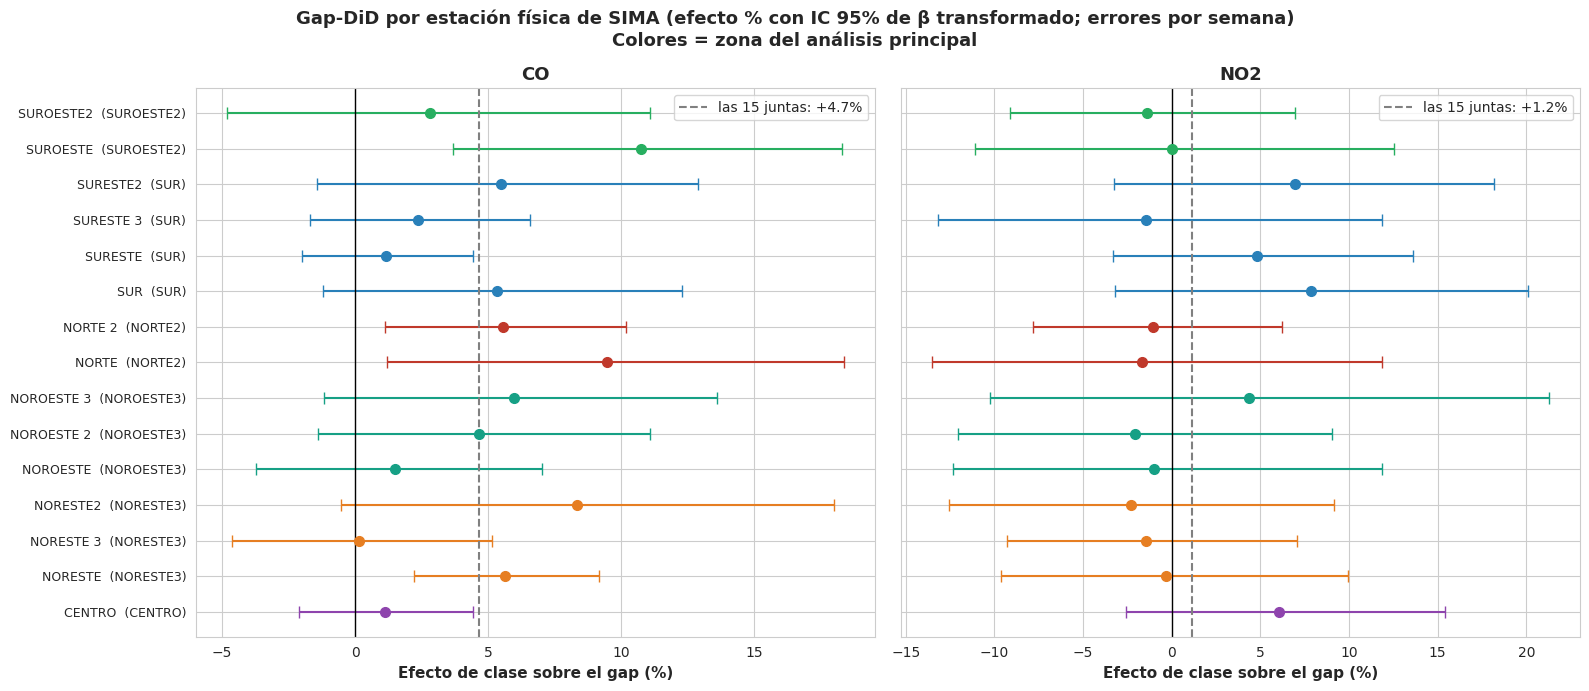

Guardado gráfico en: ../data_processed/estaciones_fisicas/01_gap_did_por_estacion_fisica.png


In [6]:
colores_zona = {'CENTRO': '#8e44ad', 'NORESTE3': '#e67e22', 'NOROESTE3': '#16a085',
                'NORTE2': '#c0392b', 'SUR': '#2980b9', 'SUROESTE2': '#27ae60'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, c in zip(axes, ['CO', 'NO2']):
    sub = tabla_estaciones[tabla_estaciones['contaminante'] == c].reset_index(drop=True)
    y_pos = np.arange(len(sub))
    for i, fila in sub.iterrows():
        color = colores_zona[fila['zona']]
        ax.errorbar(fila['pct'], i, xerr=[[fila['pct'] - fila['ci_lo_pct']],
                                          [fila['ci_hi_pct'] - fila['pct']]],
                    fmt='o', color=color, capsize=4, markersize=7)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(conjunto[c]['pct'], color='gray', linewidth=1.5, linestyle='--',
               label=f"las 15 juntas: {conjunto[c]['pct']:+.1f}%")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['estacion_fisica'] + '  (' + sub['zona'] + ')', fontsize=9)
    ax.set_title(c, fontsize=13, fontweight='bold')
    ax.set_xlabel('Efecto de clase sobre el gap (%)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle('Gap-DiD por estación física de SIMA (efecto % con IC 95% de β transformado; errores por semana)\nColores = zona del análisis principal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(estaciones_dir / '01_gap_did_por_estacion_fisica.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {estaciones_dir / '01_gap_did_por_estacion_fisica.png'}")

## 7. Lectura y el paso que queda pendiente

In [7]:
co = tabla_estaciones[tabla_estaciones['contaminante'] == 'CO']
positivos = int((co['pct'] > 0).sum())
significativos = co[co['p'] < 0.05]['estacion_fisica'].tolist()

print("=" * 70)
print("LECTURA")
print("=" * 70)
import json
co_zonas = json.load(open('../data_processed/resultados_metodos/did_franjas.json'))['hibrido']['did_franjas']['por_var']['gap_CO']
print(f"1. Con las 15 estaciones juntas el gap de CO da {conjunto['CO']['pct']:+.2f}% "
      f"(p = {conjunto['CO']['p']:.4f}):")
print(f"   consistente con el {co_zonas['pct']:+.1f}% de las 6 zonas del notebook 05; desagregar no")
print("   cambia la conclusión, la refina.")
print(f"2. Estación por estación, {positivos} de {len(co)} estaciones dan gap de CO positivo;")
print(f"   significativas individualmente: {significativos if significativos else 'ninguna'}")
print("   (cada estación sola tiene menos datos: los IC se ensanchan, es esperable).")
print("3. EXTENSIÓN NATURAL: clasificar las estaciones por la densidad de escuelas en su")
print("   radio de impacto (2-3 km según SIMA) y contrastar 'alta' vs 'baja' densidad.")
print("   Requiere georreferenciar las escuelas; la maquinaria por estación física de")
print("   este notebook queda lista para conectar esa tabla.")

print('\nFINALIZADO')

LECTURA
1. Con las 15 estaciones juntas el gap de CO da +4.66% (p = 0.0105):
   consistente con el +4.6% de las 6 zonas del notebook 05; desagregar no
   cambia la conclusión, la refina.
2. Estación por estación, 15 de 15 estaciones dan gap de CO positivo;
   significativas individualmente: ['NORESTE', 'NORTE', 'NORTE 2', 'SUROESTE']
   (cada estación sola tiene menos datos: los IC se ensanchan, es esperable).
3. EXTENSIÓN NATURAL: clasificar las estaciones por la densidad de escuelas en su
   radio de impacto (2-3 km según SIMA) y contrastar 'alta' vs 'baja' densidad.
   Requiere georreferenciar las escuelas; la maquinaria por estación física de
   este notebook queda lista para conectar esa tabla.

FINALIZADO
